In [1]:
from Policy.eps_greedy import epsilon_greedy
from Custom_Envs.easy21 import Easy21

import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Monte Carlo Control

In [2]:
def Monte_Carlo_control(space_size,env,policy,num_episodes=1000000, N0=100):
    q_val = np.zeros(space_size)
    counts = np.zeros(space_size)

    for _ in range(num_episodes):
        state_t, terminated = env.reset()
        history = []
        
        while(not terminated):
            eps = N0/(N0+np.sum(counts[state_t[0]-1,state_t[1]-1]))
            action_t = policy(q_val[state_t[0]-1,state_t[1]-1],eps)
            [state_t_1, r_t_1, terminated] = env.step(action_t)

            history.append([state_t,action_t,r_t_1,state_t_1])
            state_t = state_t_1

        cumm_r = 0
        for [s_t,a_t,r,_] in history[::-1]:
            cumm_r += r
            counts[s_t[0]-1,s_t[1]-1,a_t] += 1
            q_val[s_t[0]-1,s_t[1]-1,a_t] += (1/counts[s_t[0]-1,s_t[1]-1,a_t])*(cumm_r-q_val[s_t[0]-1,s_t[1]-1,a_t])

    return(q_val,counts)

In [3]:
Env = Easy21()
space_size = [10,21,2]
optim_q, visit_freq = Monte_Carlo_control(space_size, Env, epsilon_greedy, num_episodes=10000000, N0=10000)

In [4]:
def plot_3d_surfaces(x,y,Z,titles=(),heading=""):
    fig = make_subplots(
        rows=1, cols=len(Z),
        subplot_titles=titles,
        specs=[[{'type': 'surface'} for i in range(len(Z))]]
    )

    for idx,z in enumerate(Z):
        fig.add_trace(
            go.Surface(z=z, x=x, y=y, colorscale='Viridis', showscale=False),
            row=1, col=idx+1
        )

    fig.update_layout(title_text=heading, height=600, width=1000)
    fig.update_scenes(
        xaxis_title='Player Sum',
        yaxis_title='Dealer Showing',
        zaxis_title='Value',
    )

    fig.show()

In [5]:
X = np.arange(1,21)
Y = np.arange(1,10)
plot_3d_surfaces(X, Y, [optim_q[:,:,0], optim_q[:,:,1]], titles=["Player Hits","Player Sticks"], heading="MC Optimal Q-Value Fn")

In [6]:
X = np.arange(1,21)
Y = np.arange(1,10)
plot_3d_surfaces(X, Y, [np.max(optim_q, axis=2)], titles=[""], heading="MC Optimal State-Value Fn")

In [7]:
X = np.arange(1,21)
Y = np.arange(1,10)
plot_3d_surfaces(X, Y, [visit_freq[:,:,0], visit_freq[:,:,1]], titles=["Player Hits","Player Sticks"], heading="Visit Freq during Learning")

## N0 = 100

In [8]:
Env = Easy21()
space_size = [10,21,2]
optim_q_100, visit_freq_100 = Monte_Carlo_control(space_size, Env, epsilon_greedy, num_episodes=1000000, N0=100)

In [9]:
X = np.arange(1,21)
Y = np.arange(1,10)
plot_3d_surfaces(X, Y, [optim_q_100[:,:,0], optim_q_100[:,:,1]], titles=["Player Hits","Player Sticks"], heading="MC Optimal Q-Value Fn")

In [10]:
X = np.arange(1,21)
Y = np.arange(1,10)
plot_3d_surfaces(X, Y, [visit_freq_100[:,:,0], visit_freq_100[:,:,1]], titles=["Player Hits","Player Sticks"], heading="Visit Freq during Learning")

# SARSA Lambda

In [11]:
def SARSA_lambda(space_size,env,policy,lmbda=0.9,num_episodes=1000000,N0=100, eval=False, optim_q=None):
    q_val = np.zeros(space_size)
    counts = np.zeros(space_size)
    loss = []

    for idx in range(num_episodes):
        if(eval and idx%1==0):
            mse = np.average((optim_q-q_val)**2)
            loss.append(mse)

        state_t, terminated = env.reset()
        e_trace = np.zeros(space_size)
        
        eps = N0/(N0+np.sum(counts[state_t[0]-1,state_t[1]-1]))
        action_t = policy(q_val[state_t[0]-1,state_t[1]-1],eps)
        while(not terminated):
            [state_t_1, r_t_1, terminated] = env.step(action_t)

            if(not terminated):
                eps = N0/(N0+np.sum(counts[state_t_1[0]-1,state_t_1[1]-1]))
                action_t_1 = policy(q_val[state_t_1[0]-1,state_t_1[1]-1],eps)
                TD_error = (r_t_1 + q_val[state_t_1[0]-1,state_t_1[1]-1,action_t_1]) - q_val[state_t[0]-1,state_t[1]-1,action_t]
            else:
                TD_error = r_t_1 - q_val[state_t[0]-1,state_t[1]-1,action_t]
            
            e_trace = lmbda*e_trace
            e_trace[state_t[0]-1,state_t[1]-1,action_t] += 1
            counts[state_t[0]-1,state_t[1]-1,action_t] += 1
            q_val = q_val + (1/(counts+1))*e_trace*TD_error

            if(not terminated):
                state_t, action_t = state_t_1, action_t_1

    return(q_val,counts,loss)

In [25]:
lambda_results = {}
num_episodes=10000
N0 = 100

for lmbda in range(0,11):
    results = []
    for seed in range(5):
        np.random.seed(seed)
        Env = Easy21()
        space_size = [10,21,2]
        res = SARSA_lambda(space_size, Env, epsilon_greedy, lmbda=lmbda/10.0, num_episodes=num_episodes, N0=N0, eval=True, optim_q=optim_q)
        print(f"Run Complete for lambda: {lmbda/10.0} & seed: {seed}")
        results.append(res)
    
    lambda_results[lmbda/10.0] = results


Run Complete for lambda: 0.0 & seed: 0
Run Complete for lambda: 0.0 & seed: 1
Run Complete for lambda: 0.0 & seed: 2
Run Complete for lambda: 0.0 & seed: 3
Run Complete for lambda: 0.0 & seed: 4
Run Complete for lambda: 0.1 & seed: 0
Run Complete for lambda: 0.1 & seed: 1
Run Complete for lambda: 0.1 & seed: 2
Run Complete for lambda: 0.1 & seed: 3
Run Complete for lambda: 0.1 & seed: 4
Run Complete for lambda: 0.2 & seed: 0
Run Complete for lambda: 0.2 & seed: 1
Run Complete for lambda: 0.2 & seed: 2
Run Complete for lambda: 0.2 & seed: 3
Run Complete for lambda: 0.2 & seed: 4
Run Complete for lambda: 0.3 & seed: 0
Run Complete for lambda: 0.3 & seed: 1
Run Complete for lambda: 0.3 & seed: 2
Run Complete for lambda: 0.3 & seed: 3
Run Complete for lambda: 0.3 & seed: 4
Run Complete for lambda: 0.4 & seed: 0
Run Complete for lambda: 0.4 & seed: 1
Run Complete for lambda: 0.4 & seed: 2
Run Complete for lambda: 0.4 & seed: 3
Run Complete for lambda: 0.4 & seed: 4
Run Complete for lambda: 

<>:7: SyntaxWarning:

invalid escape sequence '\l'

<>:7: SyntaxWarning:

invalid escape sequence '\l'

/var/folders/k5/qx7l6y390hd316r0yv70rlr00000gn/T/ipykernel_22741/1216690294.py:7: SyntaxWarning:

invalid escape sequence '\l'



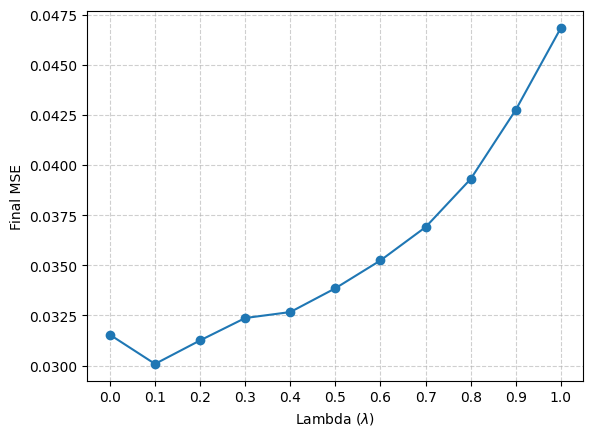

In [26]:
x_axis = list(lambda_results.keys())
y_axis = [np.average([y[2][-1] for y in x]) for x in lambda_results.values()]

plt.plot(x_axis, y_axis, marker='o', linestyle='-')
plt.xticks(x_axis)

plt.xlabel('Lambda ($\lambda$)')
plt.ylabel('Final MSE')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

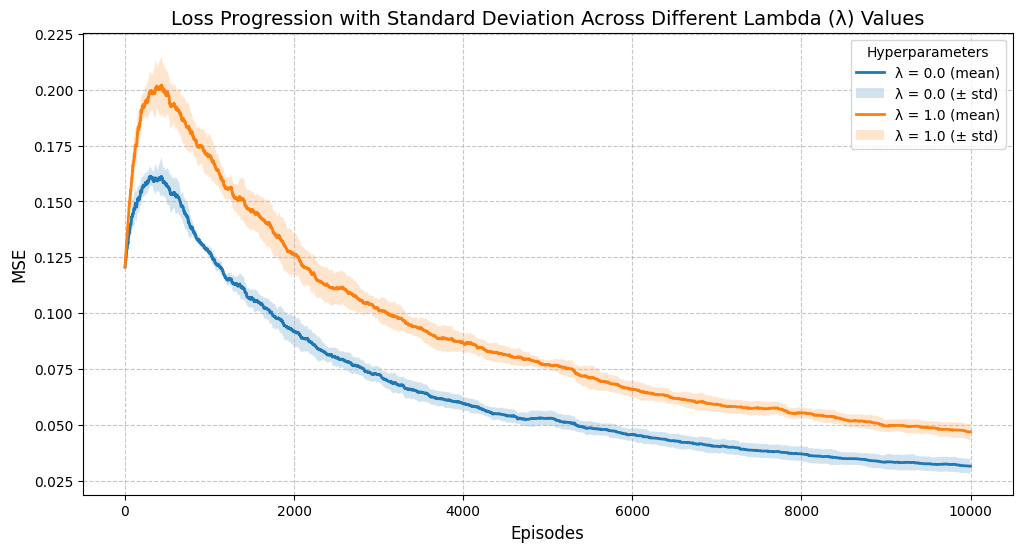

In [30]:
def plot_results_with_stats(lambda_results, num_episodes):
    """
    Plot mean and standard deviation across multiple runs for each lambda value.
    
    Args:
        lambda_results: Dictionary where keys are lambda values and values are lists of runs
                       (each run is an array of MSE values for each episode)
        num_episodes: Number of episodes
    """
    plt.figure(figsize=(12, 6))
    
    epochs = np.arange(1, num_episodes + 1)
    
    for lmbda, runs in lambda_results.items():
        if runs:  # Check if there are runs to plot
            # Convert to numpy array for easier calculations
            runs_array = np.array(runs)
            
            # Calculate mean and standard deviation across runs
            mean_values = np.mean(runs_array, axis=0)
            std_values = np.std(runs_array, axis=0)
            
            # Plot mean line
            plt.plot(epochs, mean_values, label=f'λ = {lmbda} (mean)', linewidth=2)
            
            # Add shaded region for standard deviation
            plt.fill_between(epochs, 
                            mean_values - std_values, 
                            mean_values + std_values, 
                            alpha=0.2, 
                            label=f'λ = {lmbda} (± std)')
    
    plt.title('Loss Progression with Standard Deviation Across Different Lambda (λ) Values', fontsize=14)
    plt.xlabel('Episodes', fontsize=12)
    plt.ylabel('MSE', fontsize=12)
    plt.legend(title="Hyperparameters", loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

loss_history = {}
for lmbda, res in lambda_results.items():
    if((lmbda*10)%10==0):
        loss_history[lmbda] = [x[2] for x in res]

plot_results_with_stats(loss_history,num_episodes)        


In [34]:
X = np.arange(1,21)
Y = np.arange(1,10)
SARSA_q = np.average([x[0] for x in lambda_results[0.1]],axis=0)
plot_3d_surfaces(X, Y, [SARSA_q[:,:,0], SARSA_q[:,:,1]], titles=["Player Hits","Player Sticks"], heading="SARSA Lambda Q-Value Fn for lambda=0.1")

# Function Approx

In [ ]:
def convert_to_feature(state,action):
    dealers = [[1,4], [4,7], [7,10]]
    players = [[1,6], [4,9], [7,12], [10,15], [13,18], [16,21]]
    actions = [[0],[1]]

    